In [1]:
import random  # For generating random numbers, used in selecting induced points
import os  # For operating system dependent functionality like file path operations
import numpy as np  # For numerical operations on arrays and matrices
import tensorflow as tf  # For building and training the machine learning model
import pandas as pd  # For data manipulation and analysis
import sys  # For system-specific parameters and functions
import pickle  # For serializing and de-serializing Python object structures
from scanpy import pp  # For preprocessing single-cell data
from os import path  # For pathname manipulations
from mNSF import MoranI # For calculating spatial dependeicy of each factor within each sample, using Moran's I
import scanpy as sc

I0000 00:00:1778075133.299354   96088 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Invoking __inity__.py in mNSF


In [2]:
import mNSF
from mNSF import process_multiSample
from mNSF.NSF import preprocess, misc, visualize
from mNSF import training_multiSample

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/opt/conda/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/opt/conda/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor

In [3]:
nchunk = 1  # Number of chunks per sample
L = 10  # Number of factors

# Set up paths for outputs
dir_output = "results"
os.chdir(dir_output)

mpth = path.join("models")
misc.mkdir_p(mpth)
pp = path.join(mpth, "pp")
misc.mkdir_p(pp)

In [4]:
path_to_all_selected_genes ="../../nsf-paper/200_intersection_genes.csv"

In [5]:
selected_genes = pd.read_csv(path_to_all_selected_genes)

In [6]:
id_slices = ['T1089_MT66_P0','T1090_MT65_P0', 'T1091_MT64_P32', 'T1092_MT63_P32','T1098_MT69_3M','T1099_MT67_7M' ]
nsample = len(id_slices) # Number of samples

In [10]:
def get_sample_data(id_slice):
    if id_slice in ['T1089_MT66_P0','T1090_MT65_P0']: 
        slice_path = f'../../selected_slices/{id_slice}_Visual_Sub-CTX_b100_filtered.h5ad'
    else:
        slice_path = f'../../selected_slices/{id_slice}_Visual_Sub-CTX_V12_b100_filtered.h5ad'
    #%% Data loading
    ad = sc.read_h5ad(slice_path)
    X = ad.obsm["spatial"]
       

    # список нужных генов
    genes_keep = selected_genes["real_gene_name"].astype(str).tolist()
    
    # убедиться, что в ad.var есть real_gene_name
    ad.var["real_gene_name"] = ad.var["real_gene_name"].astype(str)
    
    # оставить только те гены, которые есть и в ad, и в selected_genes
    genes_present = [g for g in genes_keep if g in set(ad.var["real_gene_name"])]
    
    # индекс по имени гена
    idx = ad.var.reset_index().groupby("real_gene_name").head(1).set_index("real_gene_name").loc[genes_present]["index"]
    
    # подмножество AnnData
    ad = ad[:, idx].copy()
    
    print(ad)
    X = pd.DataFrame(ad.obsm["spatial"], index=ad.obs_names, columns=["x", "y"])
    Y = pd.DataFrame(ad.X.toarray() if hasattr(ad.X, "toarray") else ad.X,
                 index=ad.obs_names,
                 columns=ad.var_names)
    return X, Y

In [11]:
list_D = []
list_X = []

for id_slice in id_slices:
    X, Y = get_sample_data(id_slice)
    D = process_multiSample.get_D(X, Y)
    list_D.append(D)
    list_X.append(D["X"])

AnnData object with n_obs × n_vars = 19864 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 20730 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 12761 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 15509 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'


In [12]:
list_sampleID = process_multiSample.get_listSampleID(list_D)

In [13]:
list_sampleID

[array([    0,     1,     2, ..., 19861, 19862, 19863], shape=(19864,)),
 array([19864, 19865, 19866, ..., 40591, 40592, 40593], shape=(20730,)),
 array([40594, 40595, 40596, ..., 53352, 53353, 53354], shape=(12761,)),
 array([53355, 53356, 53357, ..., 68861, 68862, 68863], shape=(15509,)),
 array([68864, 68865, 68866, ..., 86467, 86468, 86469], shape=(17606,)),
 array([ 86470,  86471,  86472, ..., 101540, 101541, 101542],
       shape=(15073,))]

In [14]:
# # get goodness-of-fit poisson deviance for each sample for each factor
# for L in [8,10, 16,24,32]:# finished running
# 	list_fit = process_multiSample.ini_multiSample(list_D, L, "nb")
# 	vec_dev = 0
# 	for ksample in range(0,nsample):
# 		dev_mnsf = visualize.gof(list_fit[ksample],list_D[ksample],Dval=None,S=3,plot=False)
# 		vec_dev= vec_dev + dev_mnsf['tr']['mean']
# 	print("L="+str(L))
# 	print("deviance="+str(vec_dev))
# 	print("")

In [15]:
nsample

6

In [16]:
# Process data chunking
list_D_chunked=list()
list_X_chunked=list()
list_chunk_mapping = list()
for id_slice in id_slices:
    X, Y = get_sample_data(id_slice)
    list_D_sampleTmp,list_X_sampleTmp, chunk_mapping = process_multiSample.get_chunked_data(X.iloc[:,:],Y.iloc[:,:],nchunk,method = "random") # choose method="balanced_kmeans“ for data chunking based on spatial coordinates
    list_D_chunked = list_D_chunked + list_D_sampleTmp
    list_X_chunked = list_X_chunked + list_X_sampleTmp
    list_chunk_mapping.append(chunk_mapping)

#  Extracts the training data from our processed data. This function prepares the data in the format required for model training.
list_Dtrain = process_multiSample.get_listDtrain(list_D_chunked)

# Set up induced points for each sample
for ksample in range(nsample):
    # Select 15% of spots as induced points
    ninduced = round(list_D_chunked[ksample]['X'].shape[0] * 0.15)
    rd_ = random.sample(range(list_D_chunked[ksample]['X'].shape[0]), ninduced)
    list_D_chunked[ksample]["Z"] = list_D_chunked[ksample]['X'][rd_, :]


AnnData object with n_obs × n_vars = 19864 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 20730 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 12761 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


...

/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 17606 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 15073 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
W0000 00:00:1778075288.474169   96088 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [17]:
list_fit = process_multiSample.ini_multiSample(list_D_chunked, L, "nb")

fit_set_loadings
1
2
3
4
5
6
6
0
1
(20,)
2
(30,)
3
(40,)
4
(50,)
5
(60,)


In [ ]:
list_fit = training_multiSample.train_model_mNSF(
    list_fit,      # Initialized model
    pp,            # Directory for preprocessing results
    list_Dtrain,    # Chunked training data
    list_D_chunked, # Full chunked dataset
    num_epochs=500,  # Number of training iterations
    nsample = nsample, # Number of samples
    nchunk = nchunk # Number of chunks
)

Temporary checkpoint directory: /tmp/tmph0tp58aq


0010 train: 1.555e+03


In [ ]:
list_fit[1]

In [ ]:
Fplot = misc.t2np(list_fit[0].sample_latent_GP_funcs(list_D_chunked[0]["X"], S=10, chol=False)).T

In [ ]:
# Fplot = process_multiSample.reorder_chunked_results(Fplot,list_chunk_mapping,list_X_chunked)

In [ ]:
hmkw = {"figsize": (15,6), "spinecolor":"white", "subplot_space": 0, "marker": ".", "s": 0.4}
fig, axes = visualize.multiheatmap(list_D[0]["X"], Fplot, (2, 5), **hmkw)

In [ ]:
hmkw = {"figsize": (15,6), "spinecolor":"white", "subplot_space": 0, "marker": ".", "s": 0.4}
fig, axes = visualize.multiheatmap(list_D[0]["X"], Fplot, (2, 5), **hmkw)

In [ ]:
hmkw = {"figsize": (15,6), "spinecolor":"white", "subplot_space": 0, "marker": ".", "s": 0.4}
fig, axes = visualize.multiheatmap(list_D[0]["X"], Fplot, (2, 5), **hmkw)

In [ ]:
fig.savefig("test_mnsf_s1.png", dpi=300, bbox_inches="tight")

In [29]:
print("The end")

The end


In [54]:
!pwd

/workspace/workspace/stereoseq_project/mNSF/results


In [30]:
## Build postprocess like in NSF 

In [31]:
from mNSF.NSF import postprocess

In [32]:
insfh = postprocess.interpret_npf(list_fit[0],list_D_chunked[0]["X"],S=10,lda_mode=False)

In [33]:
misc.pickle_to_file(insfh,f"../results/insfh_P0_sample0_L10_M3000_spde.pickle")

In [34]:
tgnames = [str(i) for i in range(1,L+1)]
hmkw = {"figsize":(15,6),"s":0.4,"marker":".","subplot_space":0,
        "spinecolor":"white"}

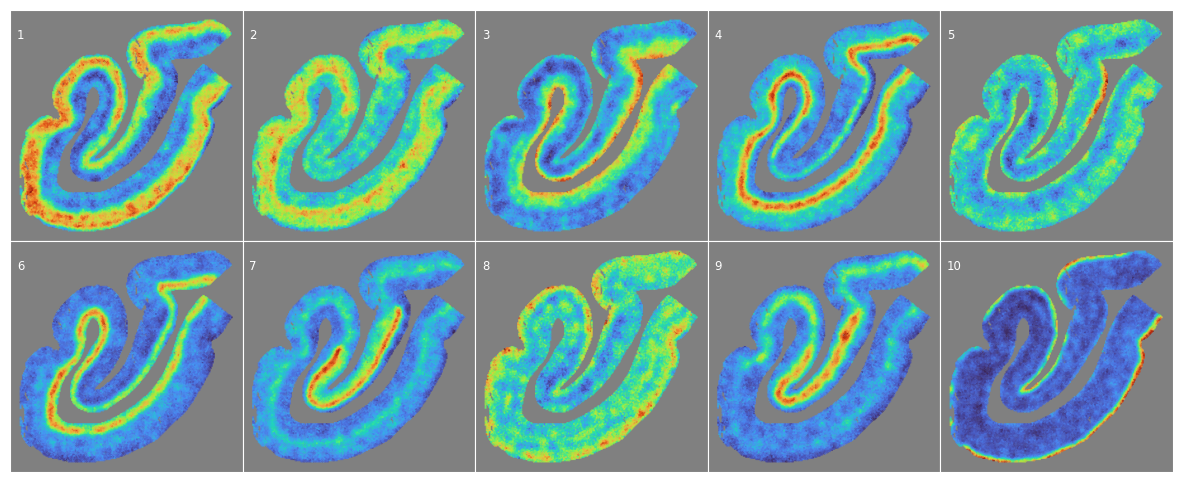

In [35]:
fig,axes=visualize.multiheatmap(list_D_chunked[0]["X"], np.sqrt(insfh["factors"]),
                                    (2,5), **hmkw)

visualize.set_titles(fig, tgnames, x=0.03, y=.88, fontsize="small", c="white",
                         ha="left", va="top")
fig.savefig(f"../results/Pall_sample0_heatmap_mnsf10_spde_spat.png",
                bbox_inches='tight', dpi=300)

[82, 70, 101, 88, 83, 43, 139, 173, 56, 158]


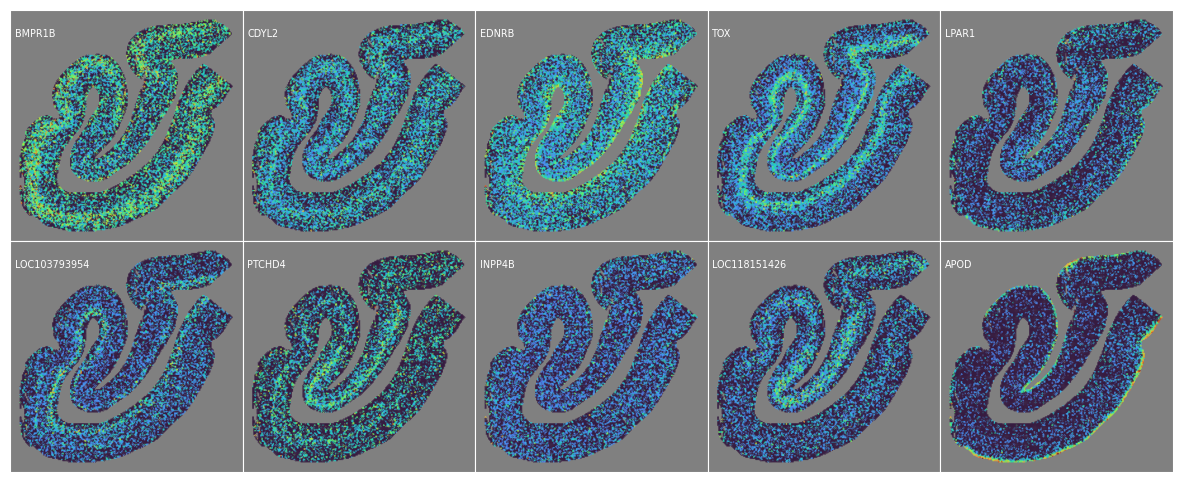

In [36]:
with tf.device("/CPU:0"): 
    W = insfh["loadings"]
    W[np.isnan(W)] = 0.0
    topgenes = W.argmax(axis=0).tolist()
    print(topgenes)
    tgnames =  Y.columns[topgenes]
    Ytg = list_D_chunked[0]["Y"][:,topgenes]/list_D_chunked[0]["sz"]
    fig,axes=visualize.multiheatmap(list_D_chunked[0]["X"], np.sqrt(Ytg), (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.02, y=.88, fontsize="x-small", c="white",
                         ha="left", va="top")
    fig.savefig(f"../results/Pall_sample0_heatmap_nsfh20_spde_spat_genes.png",
                bbox_inches='tight', dpi=300)

In [37]:
len(list_D_chunked)

6

In [38]:
insfh = postprocess.interpret_npf(list_fit[1],list_D_chunked[1]["X"],S=10,lda_mode=False)

In [39]:
misc.pickle_to_file(insfh,f"../results/insfh_P0_sample1_L10_M3000_spde.pickle")

In [40]:
tgnames = [str(i) for i in range(1,L+1)]

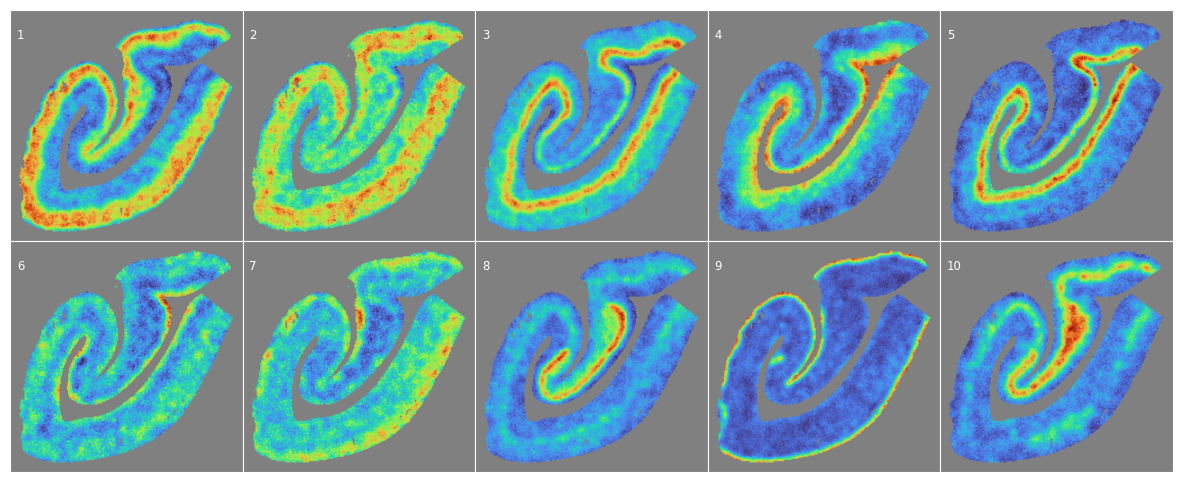

In [41]:
fig,axes=visualize.multiheatmap(list_D_chunked[1]["X"], np.sqrt(insfh["factors"]),
                                    (2,5), **hmkw)
visualize.set_titles(fig, tgnames, x=0.03, y=.88, fontsize="small", c="white",
                         ha="left", va="top")
fig.savefig(f"../results/Pall_sample1_heatmap_mnsf10_spde_spat.png",
                bbox_inches='tight', dpi=300)

[82, 153, 38, 36, 43, 83, 173, 120, 158, 56]


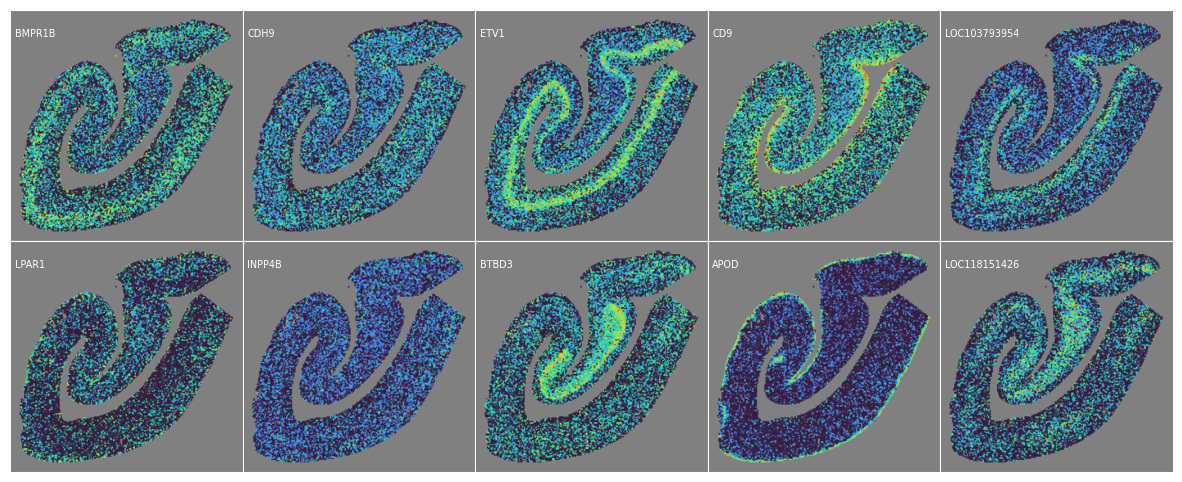

In [42]:
with tf.device("/CPU:0"): 
    W = insfh["loadings"]
    W[np.isnan(W)] = 0.0
    topgenes = W.argmax(axis=0).tolist()
    print(topgenes)
    tgnames =  Y.columns[topgenes]
    Ytg = list_D_chunked[1]["Y"][:,topgenes]/list_D_chunked[1]["sz"]
    fig,axes=visualize.multiheatmap(list_D_chunked[1]["X"], np.sqrt(Ytg), (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.02, y=.88, fontsize="x-small", c="white",
                         ha="left", va="top")
    fig.savefig(f"../results/Pall_sample1_heatmap_nsfh20_spde_spat_genes.png",
                bbox_inches='tight', dpi=300)

In [43]:
import numpy as np

Ws = [fit.W.numpy() for fit in list_fit]

for i in range(len(Ws)):
    for j in range(i + 1, len(Ws)):
        print(i, j, np.max(np.abs(Ws[i] - Ws[j])))

0 1 1.9213309
0 2 3.103265
0 3 3.4392304
0 4 3.5192075
0 5 3.5423803
1 2 3.1999044
1 3 3.3631232
1 4 3.7896721
1 5 3.4133396
2 3 1.901504
2 4 2.6636882
2 5 3.4660416
3 4 2.739953
3 5 3.4394922
4 5 2.5845222


In [44]:
from sklearn.metrics.pairwise import cosine_similarity

for i in range(len(Ws)):
    for j in range(i + 1, len(Ws)):
        sim = cosine_similarity(Ws[i].T, Ws[j].T)
        print(i, j, np.diag(sim))

0 1 [0.98871213 0.99020696 0.9858009  0.9939363  0.98277235 0.9835724
 0.9907086  0.98772496 0.9876394  0.9900171 ]
0 2 [0.95406586 0.8267336  0.92914116 0.950659   0.92744565 0.9158946
 0.93942225 0.90989494 0.943521   0.92734164]
0 3 [0.9562926  0.84531295 0.940771   0.9532331  0.92423904 0.9142244
 0.9400209  0.91807914 0.9426965  0.9140832 ]
0 4 [0.9375534  0.8372827  0.9089222  0.9169428  0.90407985 0.9007094
 0.92044777 0.8972994  0.87978804 0.90081173]
0 5 [0.92939454 0.8071723  0.89240676 0.91153944 0.8804537  0.878695
 0.90800977 0.8839742  0.93098754 0.8946327 ]
1 2 [0.9583312  0.81629515 0.926029   0.95596945 0.9496745  0.92436767
 0.9431983  0.9151325  0.9463805  0.92653763]
1 3 [0.96173924 0.84189165 0.9371807  0.95798755 0.9501487  0.9317068
 0.94613993 0.92416245 0.9470044  0.9141419 ]
1 4 [0.9477705  0.83040535 0.9154402  0.9222541  0.92413163 0.9010794
 0.9142736  0.9048804  0.886517   0.9025729 ]
1 5 [0.93934083 0.8045013  0.8948645  0.91456854 0.89684474 0.87833214
 